# Benchmark results

Every agent's traces under `traces/` scored on the 44 valid tasks, broken down by task type
(T1-T3 descriptive, T4-T7 diagnostic, T8-T10 prescriptive) and by template. Main agents have
5 seeds; the dummies and gemini-2.5-flash (baseline) have 1 (the no-tool ablation had 3 at the time of writing,
with more seeds still running).

## Summary of findings

- **The frontier models are near the insight ceiling on descriptive and diagnostic tasks and nearly indistinguishable from each other.** Claude Fable 5, Claude Sonnet 5 and both GPT-5.6 variants all sit at 4.5-4.6 overall; the two Claude models tie at 4.60 (`figures/insight_by_task_type.png`).
- **Insight drops by more than a point on prescriptive tasks, and the loss is concentrated in T9 and T10.** T8 (comparative diagnosis) is still near 5 for every real model, while T9 (targeted recommendation) and T10 (full report) average around 3 even for the best agents (`figures/insight_by_template.png`).
- **pass^5 shows the prescriptive results are unstable, not just lower.** No agent passes T10 on all five seeds, T9 is at most 0.25, and the top three agents tie at 0.42 on prescriptive tasks overall (`figures/insight_pass_k_by_task_type.png`, `figures/insight_pass_k_by_template.png`).
- **Tool selection is not what fails on prescriptive tasks.** Every real model recalls the gold tool set almost perfectly on T8-T10; the loss comes from how tools are used and what is written. The only tool-selection gaps are the Claude models on T3 and T4 (about two thirds recall) and a flat 0.83 / 0.80 on T5 / T6 shared by every model, which points to a gold-set mismatch rather than a model difference (`figures/tool_selection_by_task_type.png`, `figures/tool_selection_by_template.png`).
- **deepseek-v3.2 is the weakest of the real tool-using models on diagnostic templates.** Its T5 and T7 means are 3.7 and 3.9, its T5 pass^5 is zero, and its diagnostic path efficiency is the lowest of the main runs (`figures/insight_by_template.png`, `figures/path_efficiency_by_task_type.png`).
- **Path efficiency dips on T4 and T9 for every model.** Cross-segment comparison and targeted recommendation cost extra turns across the board; the no-tool ablation's high value here is an artefact of spending almost no turns (`figures/path_efficiency_by_template.png`).
- **Cost and latency roughly triple on T9 and T10.** The agent ordering by cost is the same in every template: Fable is about 5x Sonnet, which is about 4x GPT-5.6, with DeepSeek cheapest. DeepSeek is also the slowest main run, taking about 52 s per prescriptive task (`figures/cost_usd_by_template.png`, `figures/latency_s_by_task_type.png`).
- **gemini-2.5-flash (baseline) has a single-seed outlier on T4.** Its T4 latency (about 112 s) and cost (about $0.07) are an order of magnitude above its other templates; check those traces before quoting its numbers (`figures/latency_s_by_template.png`, `figures/cost_usd_by_template.png`).
- **The baselines behave as designed.** The null dummy scores 0 everywhere, the random dummy (a lone answer call, no tool calls) sits at about 1.6 insight with zero tool recall, and the no-tool ablation scores 0.3 insight, so the tool layer accounts for essentially all of the real models' performance (`figures/insight_by_task_type.png`, `figures/tool_selection_by_task_type.png`).

## Mean insight score by task type

Each run directory under `traces/` holds the JSONL traces of one agent x one seed plus the `scores.csv`
that `scoring.py` derived from them; the agent identity is read from the `run_start` record of the
traces, as in `summary.py`. The mean is over all scored (task, seed) pairs of an agent, restricted to
the 44 valid tasks.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))
from cx_agent_bench.scoring import load_valid_task_ids
from cx_agent_bench.summary import run_agent_id

TASK_TYPE = {**{f"T{i}": "descriptive" for i in (1, 2, 3)},
             **{f"T{i}": "diagnostic" for i in (4, 5, 6, 7)},
             **{f"T{i}": "prescriptive" for i in (8, 9, 10)}}
TYPE_ORDER = ["descriptive", "diagnostic", "prescriptive"]
# display names for the Vertex routes: the trace model field is the long
# Vertex path, so rename them everywhere the agent is reported
AGENT_NAMES = {"vertex_ai/deepseek-ai/deepseek-v3.2-maas": "deepseek-v3.2",
               "vertex_ai/gemini-2.5-flash": "gemini-2.5-flash (baseline)"}

valid = load_valid_task_ids()
frames = []
for csv in sorted((REPO / "traces").rglob("scores.csv")):
    df = pd.read_csv(csv)
    if "insight_score" not in df.columns:
        continue
    if valid is not None:
        df = df[df["task_id"].isin(valid)]
    agent = run_agent_id(csv.parent)
    df = df.assign(agent=AGENT_NAMES.get(agent, agent), run_dir=csv.parent.name)
    frames.append(df)
scores = pd.concat(frames, ignore_index=True)
scores["task_type"] = scores["task_id"].str.split("-").str[0].map(TASK_TYPE)

insight_by_type = (scores.pivot_table(index="agent", columns="task_type",
                                      values="insight_score", aggfunc="mean")
                   .reindex(columns=TYPE_ORDER))
insight_by_type["overall"] = scores.groupby("agent")["insight_score"].mean()
insight_by_type["k_seeds"] = scores.groupby("agent")["run_dir"].nunique()
insight_by_type = insight_by_type.sort_values("overall", ascending=False).round(2)
print(insight_by_type.to_string())

# pass^k: a task passes if every seed run of the agent scored insight >= 4.
# k is the number of seeds the agent has (5 for the main comparison, fewer for
# single-seed runs), so the column is strictly pass^k with k shown alongside.
PASS_THRESHOLD = 4
per_task = (scores.groupby(["agent", "task_id"])["insight_score"]
            .agg(lambda s: float((s >= PASS_THRESHOLD).all()) if s.notna().all() else np.nan)
            .reset_index(name="pass_k"))
per_task["task_type"] = per_task["task_id"].str.split("-").str[0].map(TASK_TYPE)
per_task["template"] = per_task["task_id"].str.split("-").str[0]
k = scores.groupby("agent")["run_dir"].nunique().reindex(insight_by_type.index)
pass_by_type = (per_task.pivot_table(index="agent", columns="task_type", values="pass_k", aggfunc="mean")
                .reindex(columns=TYPE_ORDER).reindex(insight_by_type.index).round(3))
pass_by_type.columns.name = None

task_type                    descriptive  diagnostic  prescriptive  overall  k_seeds
agent                                                                               
claude-fable-5                      5.00        4.90          3.68     4.60        5
claude-sonnet-5                     5.00        4.90          3.68     4.60        5
gpt-5.6-sol                         5.00        4.86          3.52     4.54        5
gpt-5.6-terra                       4.76        4.96          3.52     4.50        5
deepseek-v3.2                       4.86        4.38          3.33     4.24        5
gemini-2.5-flash (baseline)         4.43        3.83          3.00     3.80        1
dummy-random                        1.07        2.00          1.50     1.57        1
no-tool-agent                       0.20        0.59          0.12     0.34        5
dummy-null                          0.00        0.00          0.00     0.00        1


## Insight score by task type

Grouped bars, one group per agent (ordered by overall mean), one bar per task type. Saved to `figures/insight_by_task_type.png`.

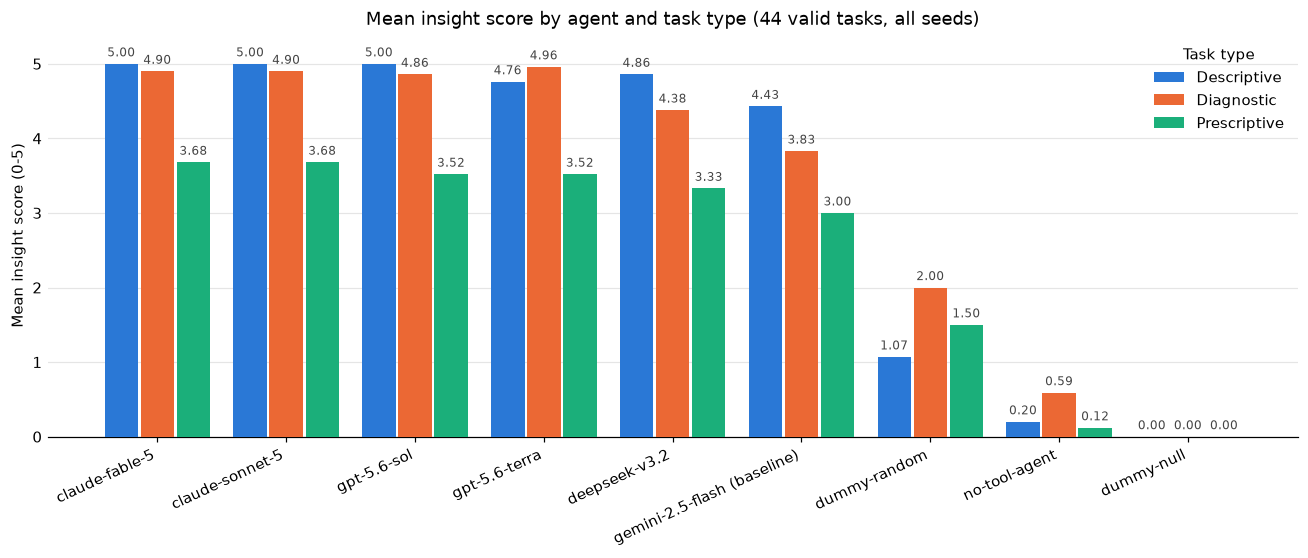

In [2]:
import matplotlib.pyplot as plt
import numpy as np

COLORS = {"descriptive": "#2a78d6", "diagnostic": "#eb6834", "prescriptive": "#1baf7a"}
agents = insight_by_type.index.tolist()
x = np.arange(len(agents))
width = 0.26

fig, ax = plt.subplots(figsize=(12, 5.2))
for i, t in enumerate(TYPE_ORDER):
    vals = insight_by_type[t].values
    bars = ax.bar(x + (i - 1) * (width + 0.02), vals, width, color=COLORS[t],
                  label=t.capitalize(), zorder=3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.06, f"{v:.2f}",
                ha="center", va="bottom", fontsize=8, color="#444444")

ax.set_ylim(0, 5.4)
ax.set_yticks(range(0, 6))
ax.set_ylabel("Mean insight score (0-5)")
ax.set_xticks(x)
ax.set_xticklabels(agents, rotation=25, ha="right")
ax.set_title("Mean insight score by agent and task type (44 valid tasks, all seeds)")
ax.yaxis.grid(True, color="#e5e5e5", zorder=0)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.legend(title="Task type", frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(REPO / "figures" / "insight_by_task_type.png", dpi=150, bbox_inches="tight")
plt.show()

## Insight score by template

Same mean, broken down by template (T1-T3 descriptive, T4-T7 diagnostic, T8-T10 prescriptive). Agents in the same order as the task-type table.

In [3]:
scores["template"] = scores["task_id"].str.split("-").str[0]
TEMPLATE_ORDER = [f"T{i}" for i in range(1, 11)]

insight_by_template = (scores.pivot_table(index="agent", columns="template",
                                          values="insight_score", aggfunc="mean")
                       .reindex(columns=TEMPLATE_ORDER)
                       .reindex(insight_by_type.index)  # same agent order as above
                       .round(2))
insight_by_template.columns.name = None
print(insight_by_template.to_string())

                               T1   T2    T3    T4    T5    T6    T7    T8    T9   T10
agent                                                                                 
claude-fable-5               5.00  5.0  5.00  4.84  5.00  4.92  4.88  4.95  3.25  2.85
claude-sonnet-5              5.00  5.0  5.00  4.88  5.00  4.92  4.84  5.00  3.20  2.85
gpt-5.6-sol                  5.00  5.0  5.00  4.96  5.00  4.92  4.60  5.00  2.75  2.80
gpt-5.6-terra                4.92  4.4  5.00  4.96  4.93  5.00  4.92  4.85  2.85  2.85
deepseek-v3.2                5.00  4.8  4.75  4.92  3.73  4.68  3.92  4.70  2.80  2.50
gemini-2.5-flash (baseline)  3.40  5.0  5.00  4.00  3.67  3.80  3.80  4.50  2.25  2.25
dummy-random                 1.40  1.2  0.50  1.60  2.33  2.40  1.80  2.00  1.50  1.00
no-tool-agent                0.56  0.0  0.00  0.36  0.93  0.76  0.44  0.00  0.00  0.35
dummy-null                   0.00  0.0  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00


## Heatmap by template

One row per agent, one column per template, sequential blue for the mean insight score. Saved to `figures/insight_by_template.png`.

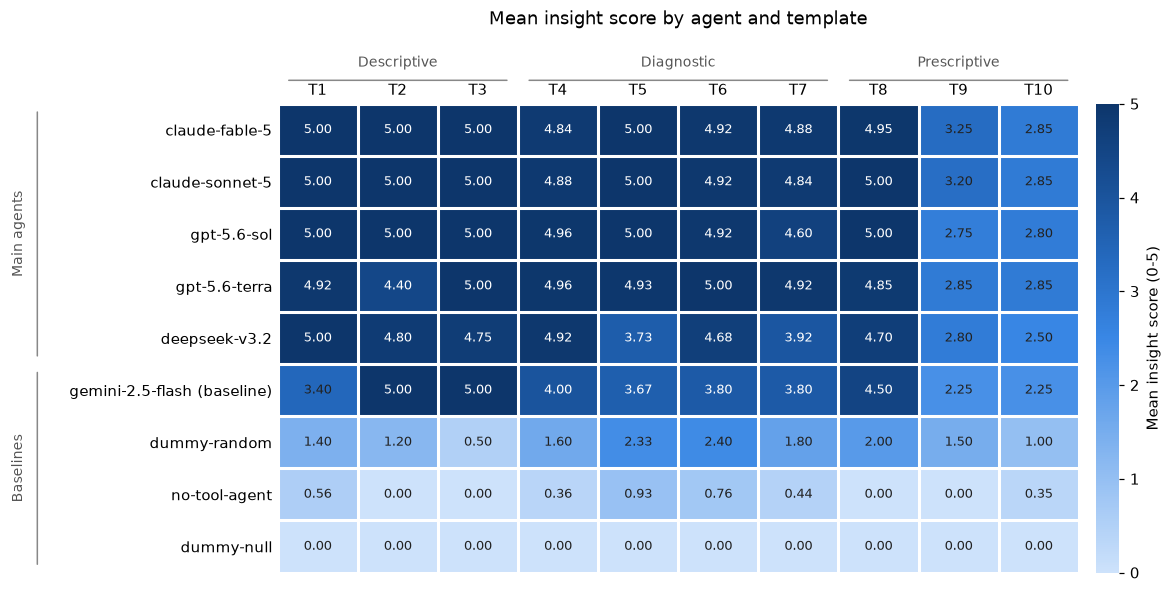

In [4]:
from matplotlib.colors import LinearSegmentedColormap

# one-hue sequential ramp (blue 100 -> 700), light = low score, dark = high
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
cmap = LinearSegmentedColormap.from_list("blue_seq", BLUE_RAMP)

mat = insight_by_template.values
labels = insight_by_template.index.tolist()

fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=5, aspect="auto")
# 2px surface gap between cells
ax.set_xticks(np.arange(-0.5, mat.shape[1]), minor=True)
ax.set_yticks(np.arange(-0.5, mat.shape[0]), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="both", length=0)

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                color="white" if v >= 3.5 else "#222222")

ax.set_xticks(range(mat.shape[1]))
ax.set_xticklabels(insight_by_template.columns)
ax.set_yticks(range(mat.shape[0]))
ax.set_yticklabels(labels)
ax.xaxis.tick_top()
# group the templates by task type along the top
for name, lo, hi in [("Descriptive", 0, 2), ("Diagnostic", 3, 6), ("Prescriptive", 7, 9)]:
    ax.annotate("", xy=(lo - 0.4, -0.95), xytext=(hi + 0.4, -0.95),
                xycoords="data", annotation_clip=False,
                arrowprops=dict(arrowstyle="-", color="#888888", lw=1))
    ax.text((lo + hi) / 2, -1.15, name, ha="center", va="bottom", fontsize=9,
            color="#555555")
# left bracket: the five-seed main agents vs the baselines. Agents are sorted
# by overall mean, so the main agents form a contiguous block at the top.
is_main = [(k[a] == 5) and not a.startswith(("no-tool", "dummy")) for a in insight_by_template.index]
n_main = sum(is_main)
assert all(is_main[:n_main]) and not any(is_main[n_main:]), "main agents are not contiguous"
for name, lo, hi in [("Main agents", 0, n_main - 1), ("Baselines", n_main, mat.shape[0] - 1)]:
    ax.annotate("", xy=(-0.30, lo - 0.4), xytext=(-0.30, hi + 0.4),
                xycoords=("axes fraction", "data"), annotation_clip=False,
                arrowprops=dict(arrowstyle="-", color="#888888", lw=1))
    ax.text(-0.315, (lo + hi) / 2, name, ha="right", va="center", rotation=90,
            fontsize=9, color="#555555", transform=ax.get_yaxis_transform())
for side in ax.spines.values():
    side.set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Mean insight score (0-5)")
cbar.outline.set_visible(False)
ax.set_title("Mean insight score by agent and template", pad=52)
fig.tight_layout()
fig.savefig(REPO / "figures" / "insight_by_template.png", dpi=150, bbox_inches="tight")
plt.show()

## Mean insight score and pass^5

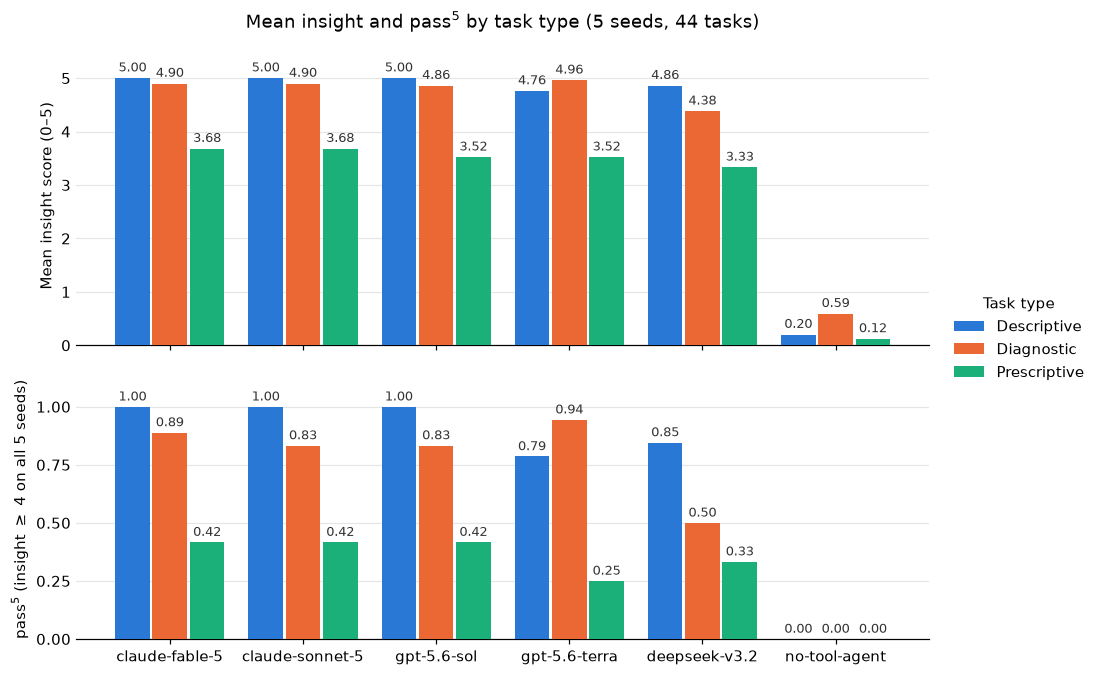

In [5]:
## Mean insight + pass^5 by task type (Fig 4.3)
# Two panels on a shared x axis, one bar per task type in each: mean insight
# score (top, 0-5) and pass^5 (bottom, 0-1), the share of tasks where all five
# seeds scored insight >= 4. Restricted to the five-seed agents so pass^k has
# the same k everywhere. Saved to figures/insight_and_pass5_by_task_type.{png,pdf}.

MAIN_AGENTS = k[k == 5].index.tolist()          # preserves the overall-mean order
assert MAIN_AGENTS, "no agent has five seeds"

ins = insight_by_type.loc[MAIN_AGENTS]
p5 = pass_by_type.loc[MAIN_AGENTS]
x = np.arange(len(MAIN_AGENTS))

fig, (ax_ins, ax_p5) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                    gridspec_kw={"height_ratios": [1.15, 1], "hspace": 0.12})

def grouped_bars(ax, table, ymax, fmt):
    for i, t in enumerate(TYPE_ORDER):
        off = (i - 1) * (width + 0.02)
        bars = ax.bar(x + off, table[t].values, width, color=COLORS[t],
                      label=t.capitalize(), zorder=3)
        for b, v in zip(bars, table[t].values):
            ax.text(b.get_x() + b.get_width() / 2, v + ymax * 0.012, fmt.format(v),
                    ha="center", va="bottom", fontsize=8.5, color="#333333")
    ax.set_ylim(0, ymax)
    ax.yaxis.grid(True, color="#e5e5e5", zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.tick_params(axis="y", length=0)

grouped_bars(ax_ins, ins, 5.6, "{:.2f}")
ax_ins.set_yticks(range(0, 6))
ax_ins.set_ylabel("Mean insight score (0–5)")
ax_ins.set_title("Mean insight and pass$^5$ by task type (5 seeds, 44 tasks)",
                 pad=12)

grouped_bars(ax_p5, p5, 1.12, "{:.2f}")
ax_p5.set_yticks(np.arange(0, 1.01, 0.25))
ax_p5.set_ylabel("pass$^5$ (insight $\\geq$ 4 on all 5 seeds)")
ax_p5.set_xticks(x)
ax_p5.set_xticklabels(MAIN_AGENTS, fontsize=10)

# one legend for both panels, outside the plot area so it never covers a bar
handles, labels = ax_ins.get_legend_handles_labels()
fig.legend(handles, labels, title="Task type", frameon=False, loc="center left",
           bbox_to_anchor=(0.91, 0.5))
fig.subplots_adjust(right=0.9)
for ext in ("png", "pdf"):
    fig.savefig(REPO / "figures" / f"insight_and_pass5_by_task_type.{ext}", dpi=200,
                bbox_inches="tight")
plt.show()

## Tool selection accuracy

Recall of the gold tool set (order and arguments ignored), same layout as the insight charts. The no-tool ablation and the null dummy call no tools, so they sit at zero by construction. Saved to `figures/tool_selection_by_task_type.png` and `figures/tool_selection_by_template.png`.

                             descriptive  diagnostic  prescriptive
agent                                                             
claude-fable-5                     0.869       0.822         1.000
claude-sonnet-5                    0.886       0.813         0.979
gpt-5.6-sol                        1.000       0.917         0.983
gpt-5.6-terra                      1.000       0.894         0.975
deepseek-v3.2                      0.979       0.928         0.996
gemini-2.5-flash (baseline)        0.929       0.861         1.000
dummy-random                       0.000       0.000         0.000
no-tool-agent                      0.000       0.000         0.000
dummy-null                         0.000       0.000         0.000


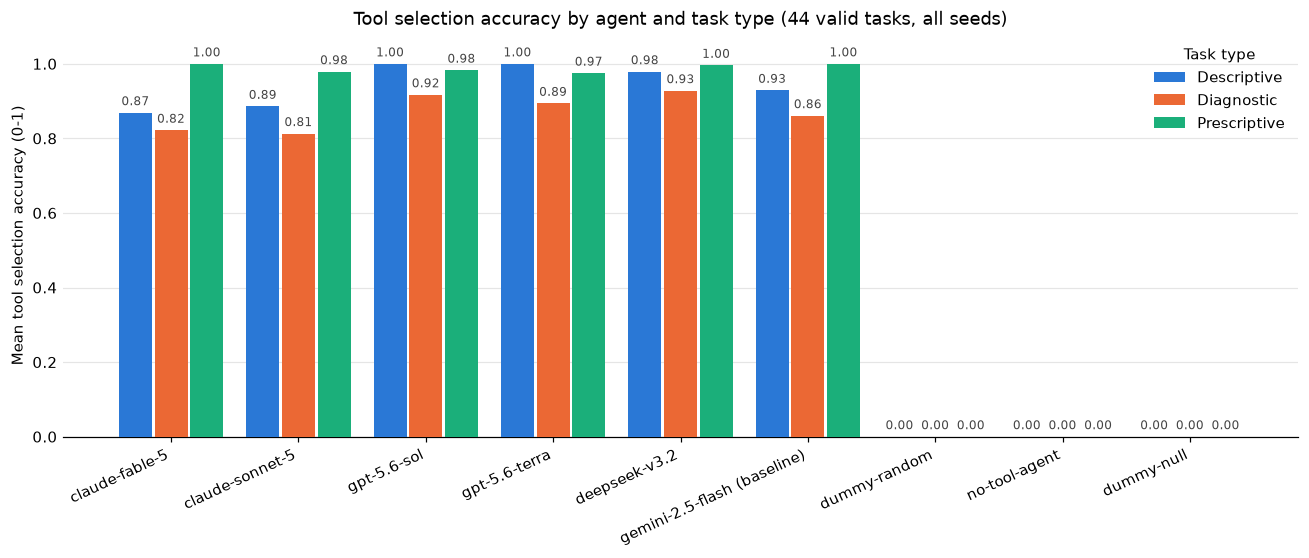

In [6]:
tsa_by_type = (scores.pivot_table(index="agent", columns="task_type",
                                  values="tool_selection_accuracy", aggfunc="mean")
               .reindex(columns=TYPE_ORDER).reindex(insight_by_type.index).round(3))
tsa_by_type.columns.name = None
print(tsa_by_type.to_string())

agents = tsa_by_type.index.tolist()
x = np.arange(len(agents))
fig, ax = plt.subplots(figsize=(12, 5.2))
for i, t in enumerate(TYPE_ORDER):
    vals = tsa_by_type[t].values
    bars = ax.bar(x + (i - 1) * (width + 0.02), vals, width, color=COLORS[t],
                  label=t.capitalize(), zorder=3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.2f}",
                ha="center", va="bottom", fontsize=8, color="#444444")
ax.set_ylim(0, 1.08)
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.set_ylabel("Mean tool selection accuracy (0-1)")
ax.set_xticks(x)
ax.set_xticklabels(agents, rotation=25, ha="right")
ax.set_title("Tool selection accuracy by agent and task type (44 valid tasks, all seeds)")
ax.yaxis.grid(True, color="#e5e5e5", zorder=0)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.legend(title="Task type", frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(REPO / "figures" / "tool_selection_by_task_type.png", dpi=150, bbox_inches="tight")
plt.show()

                               T1    T2     T3    T4     T5    T6     T7    T8    T9    T10
agent                                                                                      
claude-fable-5               0.90  1.00  0.667  0.66  0.833  0.80  1.000  1.00  1.00  1.000
claude-sonnet-5              0.92  1.00  0.700  0.68  0.833  0.80  0.947  0.95  1.00  0.988
gpt-5.6-sol                  1.00  1.00  1.000  1.00  0.833  0.80  1.000  1.00  1.00  0.950
gpt-5.6-terra                1.00  1.00  1.000  0.92  0.833  0.80  1.000  1.00  0.95  0.975
deepseek-v3.2                1.00  0.98  0.950  1.00  0.833  0.84  1.000  1.00  1.00  0.988
gemini-2.5-flash (baseline)  0.80  1.00  1.000  0.90  0.833  0.80  0.900  1.00  1.00  1.000
dummy-random                 0.00  0.00  0.000  0.00  0.000  0.00  0.000  0.00  0.00  0.000
no-tool-agent                0.00  0.00  0.000  0.00  0.000  0.00  0.000  0.00  0.00  0.000
dummy-null                   0.00  0.00  0.000  0.00  0.000  0.00  0.000  0.00  

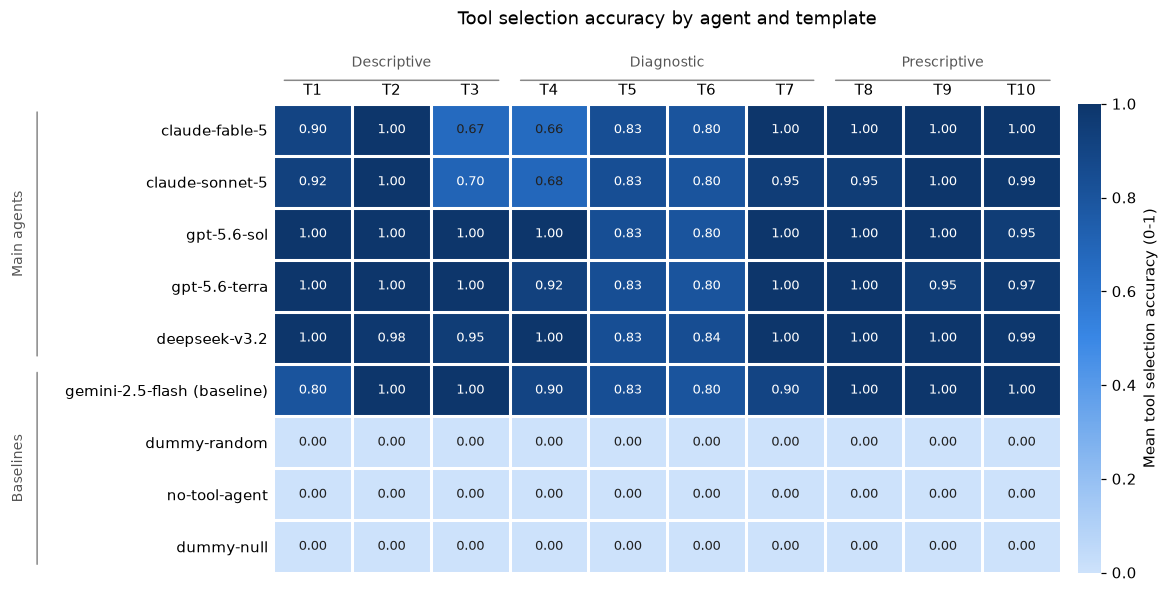

In [7]:
tsa_by_template = (scores.pivot_table(index="agent", columns="template",
                                      values="tool_selection_accuracy", aggfunc="mean")
                   .reindex(columns=TEMPLATE_ORDER).reindex(insight_by_type.index).round(3))
tsa_by_template.columns.name = None
print(tsa_by_template.to_string())

mat = tsa_by_template.values
labels = tsa_by_template.index.tolist()
fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(np.arange(-0.5, mat.shape[1]), minor=True)
ax.set_yticks(np.arange(-0.5, mat.shape[0]), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="both", length=0)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                color="white" if v >= 0.7 else "#222222")
ax.set_xticks(range(mat.shape[1]))
ax.set_xticklabels(tsa_by_template.columns)
ax.set_yticks(range(mat.shape[0]))
ax.set_yticklabels(labels)
ax.xaxis.tick_top()
for name, lo, hi in [("Descriptive", 0, 2), ("Diagnostic", 3, 6), ("Prescriptive", 7, 9)]:
    ax.annotate("", xy=(lo - 0.4, -0.95), xytext=(hi + 0.4, -0.95),
                xycoords="data", annotation_clip=False,
                arrowprops=dict(arrowstyle="-", color="#888888", lw=1))
    ax.text((lo + hi) / 2, -1.15, name, ha="center", va="bottom", fontsize=9,
            color="#555555")
# left bracket: main agents vs baselines, same rule as the insight heatmap
is_main = [(k[a] == 5) and not a.startswith(("no-tool", "dummy")) for a in tsa_by_template.index]
n_main = sum(is_main)
assert all(is_main[:n_main]) and not any(is_main[n_main:]), "main agents are not contiguous"
for name, lo, hi in [("Main agents", 0, n_main - 1), ("Baselines", n_main, mat.shape[0] - 1)]:
    ax.annotate("", xy=(-0.30, lo - 0.4), xytext=(-0.30, hi + 0.4),
                xycoords=("axes fraction", "data"), annotation_clip=False,
                arrowprops=dict(arrowstyle="-", color="#888888", lw=1))
    ax.text(-0.315, (lo + hi) / 2, name, ha="right", va="center", rotation=90,
            fontsize=9, color="#555555", transform=ax.get_yaxis_transform())
for side in ax.spines.values():
    side.set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Mean tool selection accuracy (0-1)")
cbar.outline.set_visible(False)
ax.set_title("Tool selection accuracy by agent and template", pad=52)
fig.tight_layout()
fig.savefig(REPO / "figures" / "tool_selection_by_template.png", dpi=150, bbox_inches="tight")
plt.show()

### Main agents

The same heatmap restricted to the five-seed main agents. Saved to `figures/tool_selection_by_template_main.png`.

                   T1    T2     T3    T4     T5    T6     T7    T8    T9    T10
agent                                                                          
claude-fable-5   0.90  1.00  0.667  0.66  0.833  0.80  1.000  1.00  1.00  1.000
claude-sonnet-5  0.92  1.00  0.700  0.68  0.833  0.80  0.947  0.95  1.00  0.988
gpt-5.6-sol      1.00  1.00  1.000  1.00  0.833  0.80  1.000  1.00  1.00  0.950
gpt-5.6-terra    1.00  1.00  1.000  0.92  0.833  0.80  1.000  1.00  0.95  0.975
deepseek-v3.2    1.00  0.98  0.950  1.00  0.833  0.84  1.000  1.00  1.00  0.988


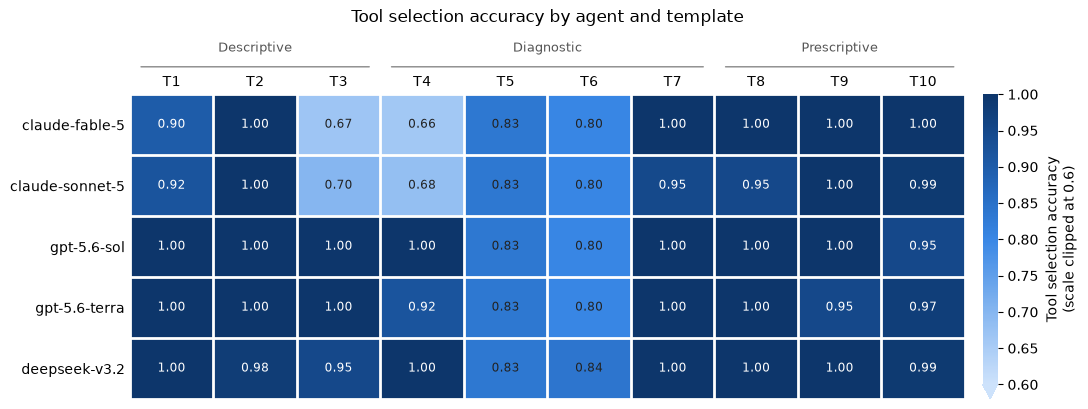

In [8]:
# tool selection by template, main agents + the no-tool ablation only
main_agents = [a for a in tsa_by_template.index
               if k[a] == 5 and not a.startswith(("no-tool", "dummy"))]
subset = tsa_by_template.loc[main_agents]
print(subset.to_string())

mat = subset.values
fig, ax = plt.subplots(figsize=(11, 4.2))
# colour scale clipped to 0.6-1.0 so the ramp is spent on the range where the
# main agents actually differ; anything below 0.6 is the lightest step and
# the colourbar arrow marks the clipping
VMIN = 0.6
im = ax.imshow(mat, cmap=cmap, vmin=VMIN, vmax=1, aspect="auto")
ax.set_xticks(np.arange(-0.5, mat.shape[1]), minor=True)
ax.set_yticks(np.arange(-0.5, mat.shape[0]), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="both", length=0)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                color="white" if v >= VMIN + 0.7 * (1 - VMIN) else "#222222")
ax.set_xticks(range(mat.shape[1]))
ax.set_xticklabels(subset.columns)
ax.set_yticks(range(mat.shape[0]))
ax.set_yticklabels(subset.index)
ax.xaxis.tick_top()
for name, lo, hi in [("Descriptive", 0, 2), ("Diagnostic", 3, 6), ("Prescriptive", 7, 9)]:
    ax.annotate("", xy=(lo - 0.4, -0.95), xytext=(hi + 0.4, -0.95),
                xycoords="data", annotation_clip=False,
                arrowprops=dict(arrowstyle="-", color="#888888", lw=1))
    ax.text((lo + hi) / 2, -1.15, name, ha="center", va="bottom", fontsize=9,
            color="#555555")
for side in ax.spines.values():
    side.set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, extend="min")
cbar.set_label("Tool selection accuracy" + chr(10) + "(scale clipped at 0.6)")
cbar.outline.set_visible(False)
ax.set_title("Tool selection accuracy by agent and template",
             pad=52)
fig.tight_layout()
fig.savefig(REPO / "figures" / "tool_selection_by_template_main.png", dpi=150, bbox_inches="tight")
plt.show()

## Remaining metrics

Helpers so each metric is one call: a grouped bar chart by task type and a heatmap by template, with the table printed above each. Figures are saved as `figures/<metric>_by_task_type.png` and `figures/<metric>_by_template.png`.

In [9]:
def bar_by_type(table, ylabel, title, fname, fmt="{:.2f}", ymax=None):
    """Grouped bars: one group per agent, one bar per task type."""
    agents = table.index.tolist()
    x = np.arange(len(agents))
    top = ymax if ymax is not None else np.nanmax(table.values) * 1.08
    fig, ax = plt.subplots(figsize=(12, 5.2))
    for i, t in enumerate(TYPE_ORDER):
        vals = table[t].values
        bars = ax.bar(x + (i - 1) * (width + 0.02), np.nan_to_num(vals), width,
                      color=COLORS[t], label=t.capitalize(), zorder=3)
        for b, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(b.get_x() + b.get_width() / 2, v + top * 0.012, fmt.format(v),
                        ha="center", va="bottom", fontsize=8, color="#444444")
    ax.set_ylim(0, top)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(agents, rotation=25, ha="right")
    ax.set_title(title)
    ax.yaxis.grid(True, color="#e5e5e5", zorder=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.legend(title="Task type", frameon=False, loc="upper right")
    fig.tight_layout()
    fig.savefig(REPO / "figures" / fname, dpi=150, bbox_inches="tight")
    plt.show()


def heatmap_by_template(table, cbar_label, title, fname, fmt="{:.2f}", vmax=None):
    """One row per agent, one column per template, sequential blue."""
    mat = table.values.astype(float)
    top = vmax if vmax is not None else np.nanmax(mat)
    labels = table.index.tolist()
    fig, ax = plt.subplots(figsize=(11, 5.5))
    im = ax.imshow(np.nan_to_num(mat), cmap=cmap, vmin=0, vmax=top, aspect="auto")
    ax.set_xticks(np.arange(-0.5, mat.shape[1]), minor=True)
    ax.set_yticks(np.arange(-0.5, mat.shape[0]), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="both", length=0)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            ax.text(j, i, "n/a" if np.isnan(v) else fmt.format(v), ha="center",
                    va="center", fontsize=8.5,
                    color="white" if (not np.isnan(v) and v >= 0.7 * top) else "#222222")
    ax.set_xticks(range(mat.shape[1]))
    ax.set_xticklabels(table.columns)
    ax.set_yticks(range(mat.shape[0]))
    ax.set_yticklabels(labels)
    ax.xaxis.tick_top()
    for name, lo, hi in [("Descriptive", 0, 2), ("Diagnostic", 3, 6), ("Prescriptive", 7, 9)]:
        ax.annotate("", xy=(lo - 0.4, -0.95), xytext=(hi + 0.4, -0.95),
                    xycoords="data", annotation_clip=False,
                    arrowprops=dict(arrowstyle="-", color="#888888", lw=1))
        ax.text((lo + hi) / 2, -1.15, name, ha="center", va="bottom", fontsize=9,
                color="#555555")
    for side in ax.spines.values():
        side.set_visible(False)
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(cbar_label)
    cbar.outline.set_visible(False)
    ax.set_title(title, pad=52)
    fig.tight_layout()
    fig.savefig(REPO / "figures" / fname, dpi=150, bbox_inches="tight")
    plt.show()


def by_type(metric, digits=3):
    t = (scores.pivot_table(index="agent", columns="task_type", values=metric, aggfunc="mean")
         .reindex(columns=TYPE_ORDER).reindex(insight_by_type.index).round(digits))
    t.columns.name = None
    return t


def by_template(metric, digits=3):
    t = (scores.pivot_table(index="agent", columns="template", values=metric, aggfunc="mean")
         .reindex(columns=TEMPLATE_ORDER).reindex(insight_by_type.index).round(digits))
    t.columns.name = None
    return t


def metric_charts(metric, short, unit_label, fmt="{:.2f}", ymax=None, digits=3):
    t = by_type(metric, digits); print(t.to_string(), "\n")
    bar_by_type(t, f"Mean {unit_label}", f"{short} by agent and task type (44 valid tasks, all seeds)",
                f"{metric}_by_task_type.png", fmt=fmt, ymax=ymax)
    m = by_template(metric, digits); print(m.to_string())
    heatmap_by_template(m, f"Mean {unit_label}", f"{short} by agent and template",
                        f"{metric}_by_template.png", fmt=fmt, vmax=ymax)

### Path efficiency

gold steps / agent non-answer turns, capped at 1. Errors count as turns.

                             descriptive  diagnostic  prescriptive
agent                                                             
claude-fable-5                     1.000       0.842         0.903
claude-sonnet-5                    1.000       0.811         0.889
gpt-5.6-sol                        1.000       0.858         0.875
gpt-5.6-terra                      1.000       0.897         0.837
deepseek-v3.2                      0.986       0.657         0.807
gemini-2.5-flash (baseline)        0.857       0.623         0.847
dummy-random                       0.000       0.000         0.000
no-tool-agent                      0.786       0.892         1.000
dummy-null                         0.000       0.000         0.000 

                                T1     T2     T3     T4     T5     T6     T7     T8     T9    T10
agent                                                                                            
claude-fable-5               1.000  1.000  1.000  0.696  1.000  0

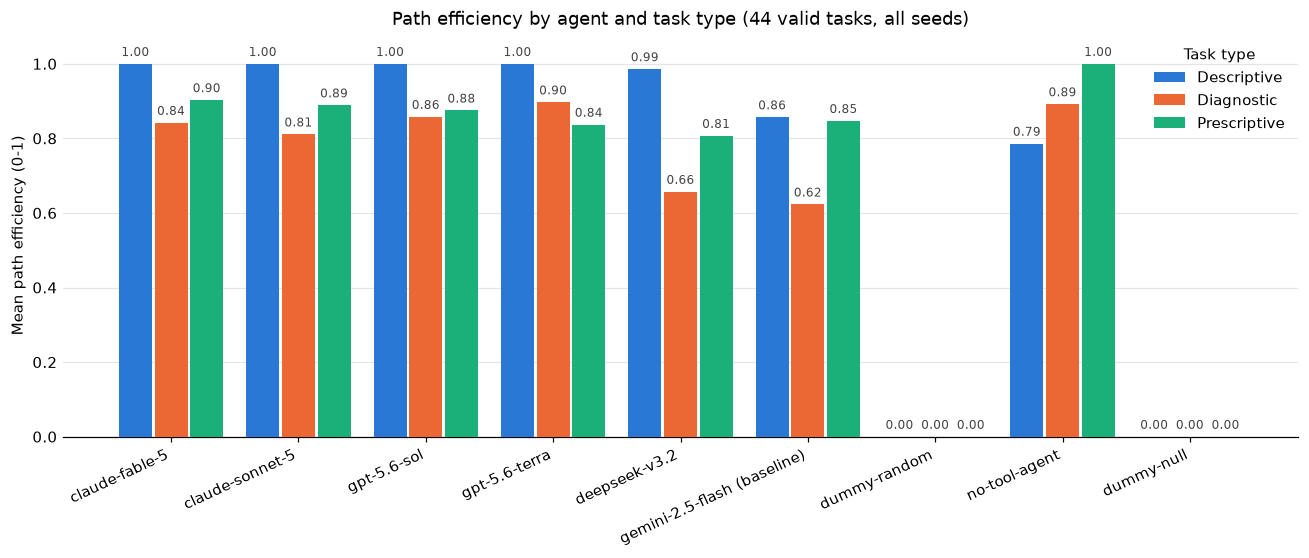

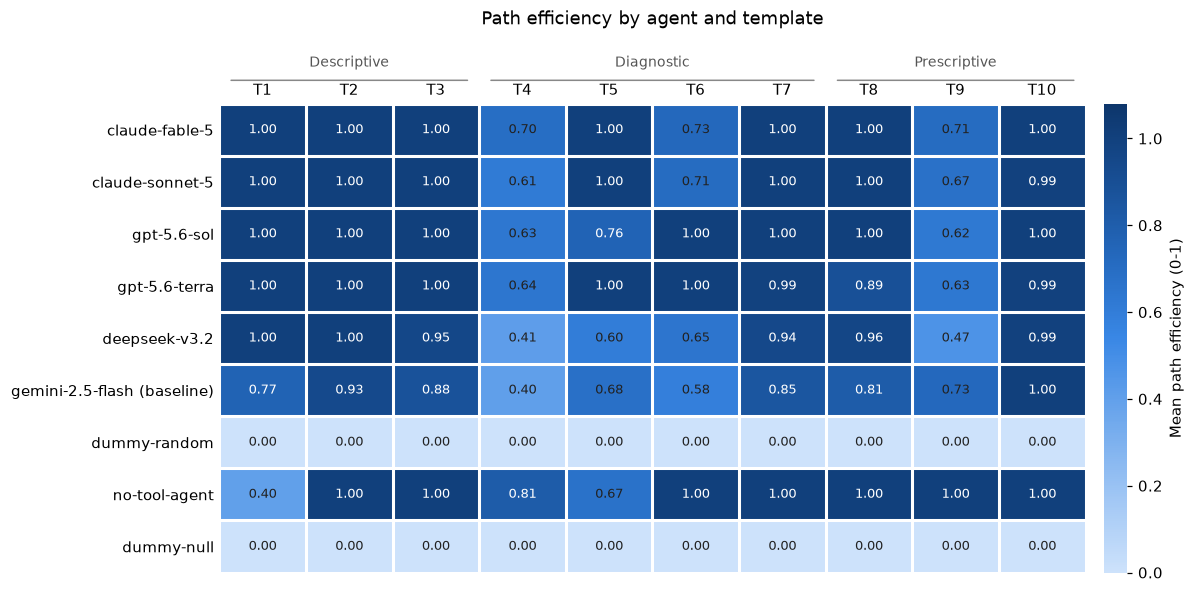

In [10]:
metric_charts("path_efficiency", "Path efficiency", "path efficiency (0-1)", ymax=1.08)

### Cost per task (USD)

Gateway-reported cost where available, else list price. Dummies and the no-tool ablation report no cost.

                             descriptive  diagnostic  prescriptive
agent                                                             
claude-fable-5                    0.1099      0.1636        0.3920
claude-sonnet-5                   0.0230      0.0380        0.0899
gpt-5.6-sol                       0.0057      0.0091        0.0214
gpt-5.6-terra                     0.0029      0.0045        0.0116
deepseek-v3.2                     0.0012      0.0020        0.0065
gemini-2.5-flash (baseline)       0.0029      0.0235        0.0075
dummy-random                         NaN         NaN           NaN
no-tool-agent                     0.0023      0.0029        0.0031
dummy-null                           NaN         NaN           NaN 

                                 T1      T2      T3      T4      T5      T6      T7      T8      T9     T10
agent                                                                                                      
claude-fable-5               0.1017  0.1070  

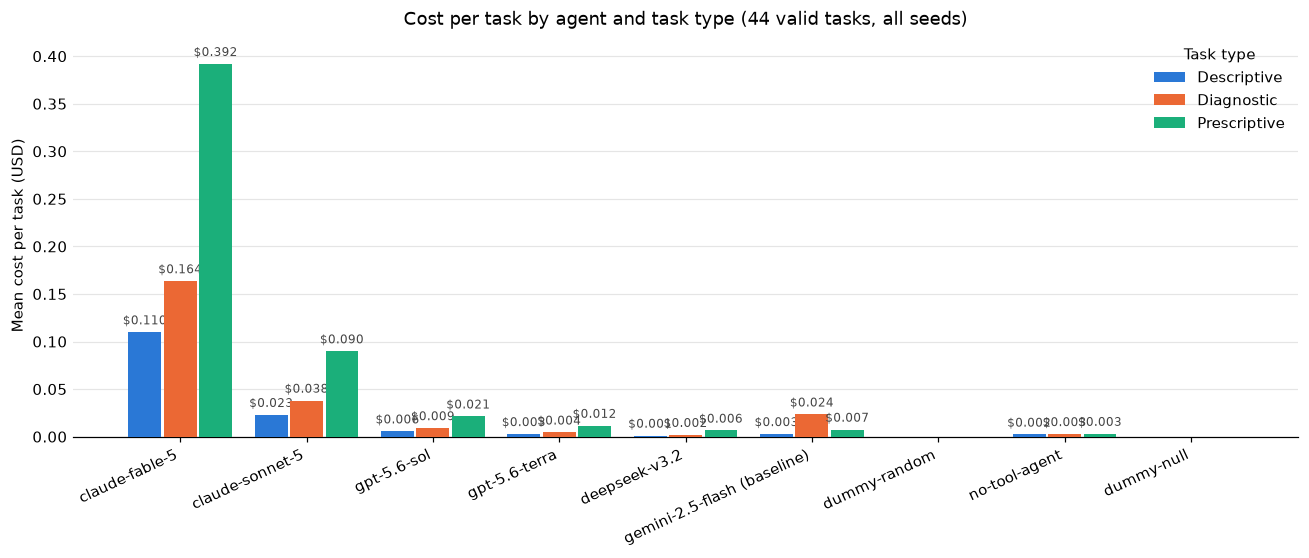

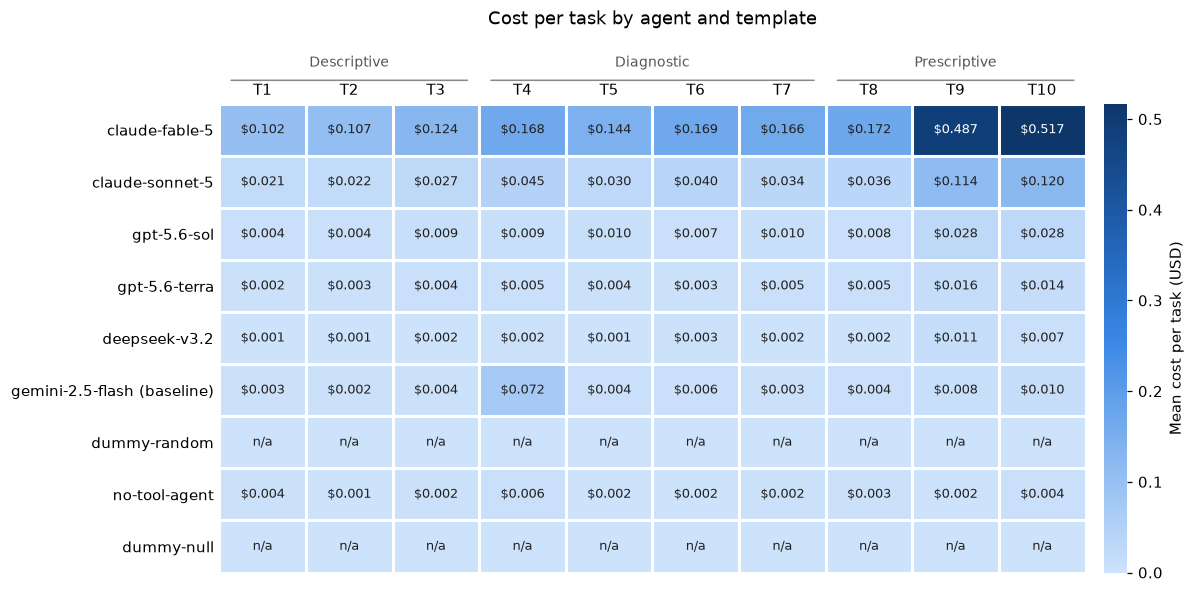

In [11]:
metric_charts("cost_usd", "Cost per task", "cost per task (USD)", fmt="${:.3f}", digits=4)

### Latency per task (seconds)

                             descriptive  diagnostic  prescriptive
agent                                                             
claude-fable-5                      11.3        17.7          37.5
claude-sonnet-5                      6.9        12.5          32.6
gpt-5.6-sol                          6.9         9.2          18.3
gpt-5.6-terra                        5.9         7.3          15.9
deepseek-v3.2                       13.7        23.2          51.6
gemini-2.5-flash (baseline)          5.3        38.0          14.3
dummy-random                         0.0         0.0           0.0
no-tool-agent                        5.5         7.1           7.0
dummy-null                           0.0         0.0           0.0 

                               T1    T2    T3     T4    T5    T6    T7    T8    T9   T10
agent                                                                                   
claude-fable-5               10.8  11.0  12.3   18.2  15.6  19.7  16.5  18.6  42.1 

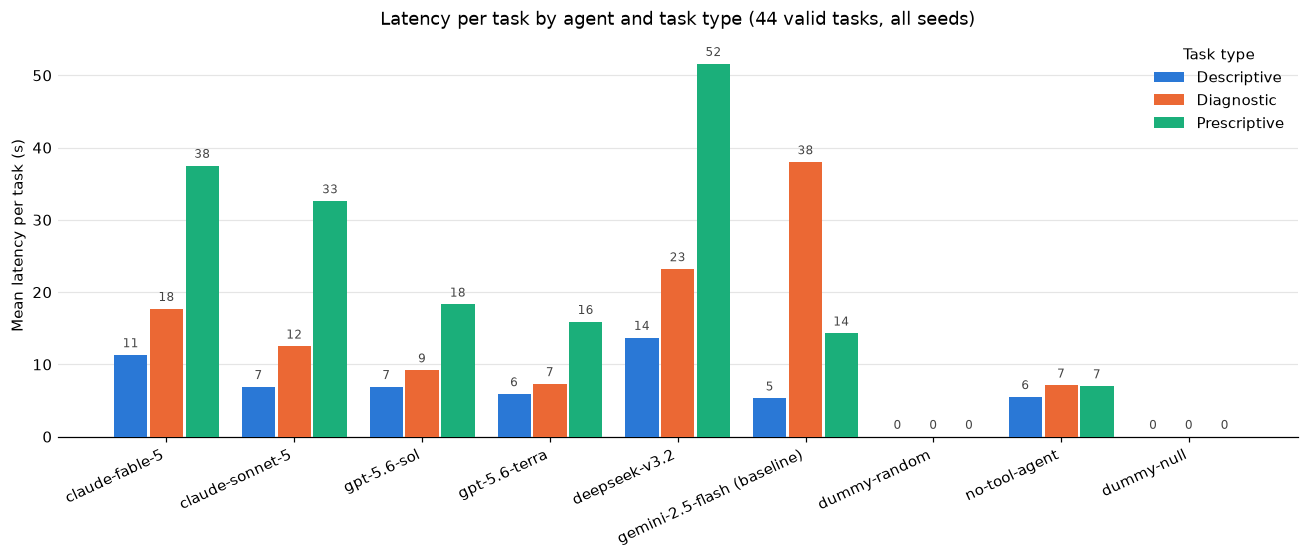

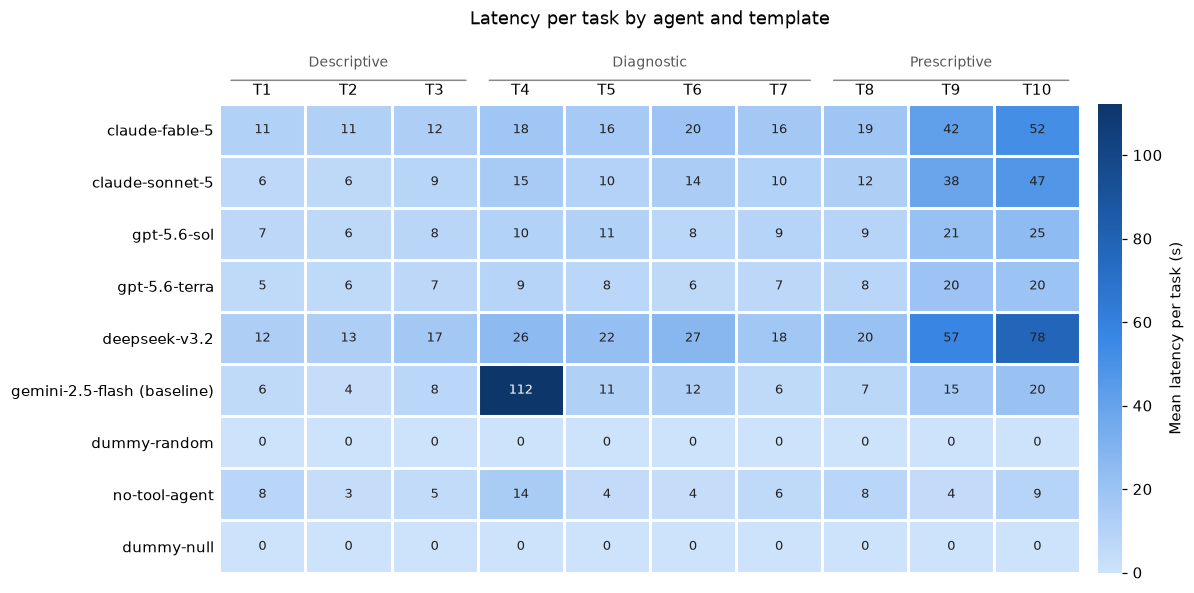

In [12]:
metric_charts("latency_s", "Latency per task", "latency per task (s)", fmt="{:.0f}", digits=1)

### Insight pass^k

Share of tasks where every seed run scored insight >= 4. This is pass^5 for the five-seed agents; single-seed agents reduce to pass@1.

                             descriptive  diagnostic  prescriptive  k
agent                                                                
claude-fable-5                     1.000       0.889         0.417  5
claude-sonnet-5                    1.000       0.833         0.417  5
gpt-5.6-sol                        1.000       0.833         0.417  5
gpt-5.6-terra                      0.786       0.944         0.250  5
deepseek-v3.2                      0.846       0.500         0.333  5
gemini-2.5-flash (baseline)        0.857       0.556         0.250  1
dummy-random                       0.000       0.000         0.000  1
no-tool-agent                      0.000       0.000         0.000  5
dummy-null                         0.000       0.000         0.000  1 

                              T1   T2    T3   T4     T5   T6   T7    T8    T9  T10  k
agent                                                                                
claude-fable-5               1.0  1.0  1.00  1.0  1.000 

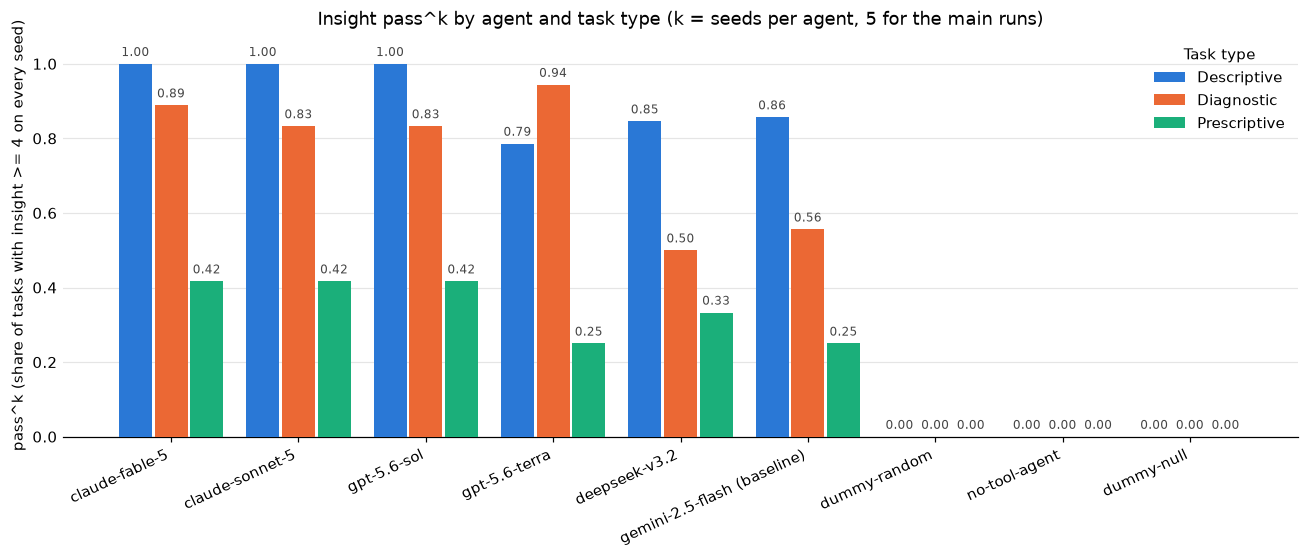

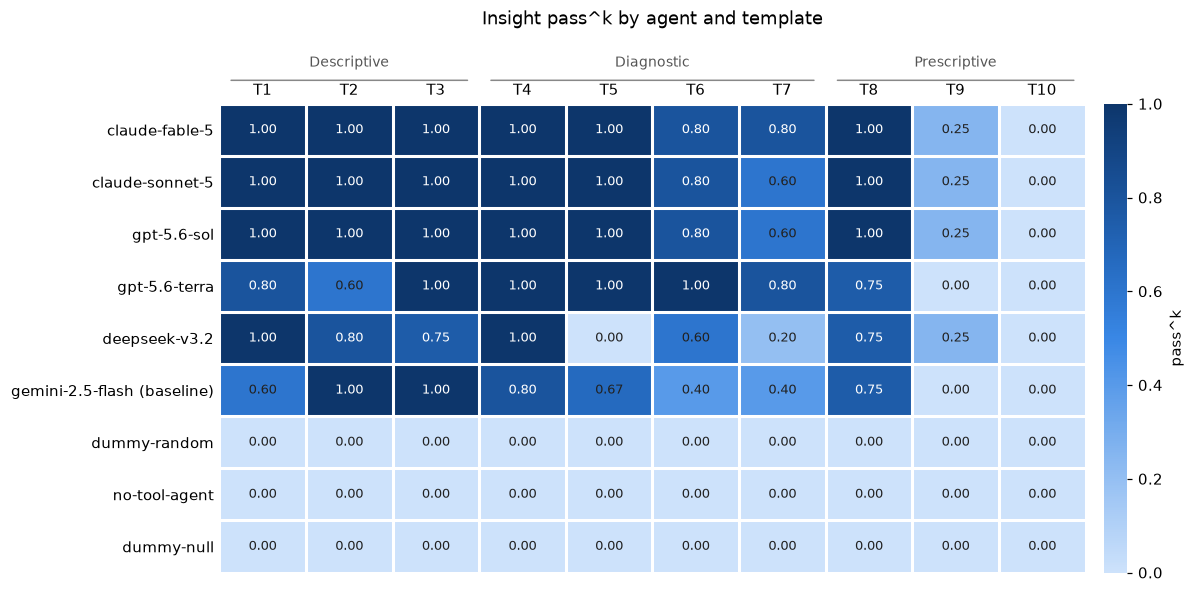

In [13]:
# per_task, k and pass_by_type are built in the load cell at the top
print(pass_by_type.assign(k=k).to_string(), "\n")
bar_by_type(pass_by_type, "pass^k (share of tasks with insight >= 4 on every seed)",
            "Insight pass^k by agent and task type (k = seeds per agent, 5 for the main runs)",
            "insight_pass_k_by_task_type.png", ymax=1.08)

pass_by_template = (per_task.pivot_table(index="agent", columns="template", values="pass_k", aggfunc="mean")
                    .reindex(columns=TEMPLATE_ORDER).reindex(insight_by_type.index).round(3))
pass_by_template.columns.name = None
print(pass_by_template.assign(k=k).to_string())
heatmap_by_template(pass_by_template, "pass^k", "Insight pass^k by agent and template",
                    "insight_pass_k_by_template.png", vmax=1.0)

## Tool selection accuracy vs insight score

Each small point is one task for one agent, both metrics averaged over its seeds. The large marker is the agent's mean. The table gives the per-agent means and the Pearson correlation across its 44 tasks. Saved to `figures/tool_selection_vs_insight.png`.

                             tool_selection_accuracy  insight_score  pearson_r
agent                                                                         
claude-fable-5                                 0.886          4.600     -0.212
claude-sonnet-5                                0.882          4.600     -0.222
gpt-5.6-sol                                    0.961          4.536     -0.011
gpt-5.6-terra                                  0.950          4.500     -0.109
deepseek-v3.2                                  0.963          4.245      0.007
gemini-2.5-flash (baseline)                    0.920          3.795      0.519
dummy-random                                   0.000          1.568        NaN
no-tool-agent                                  0.000          0.336        NaN
dummy-null                                     0.000          0.000        NaN


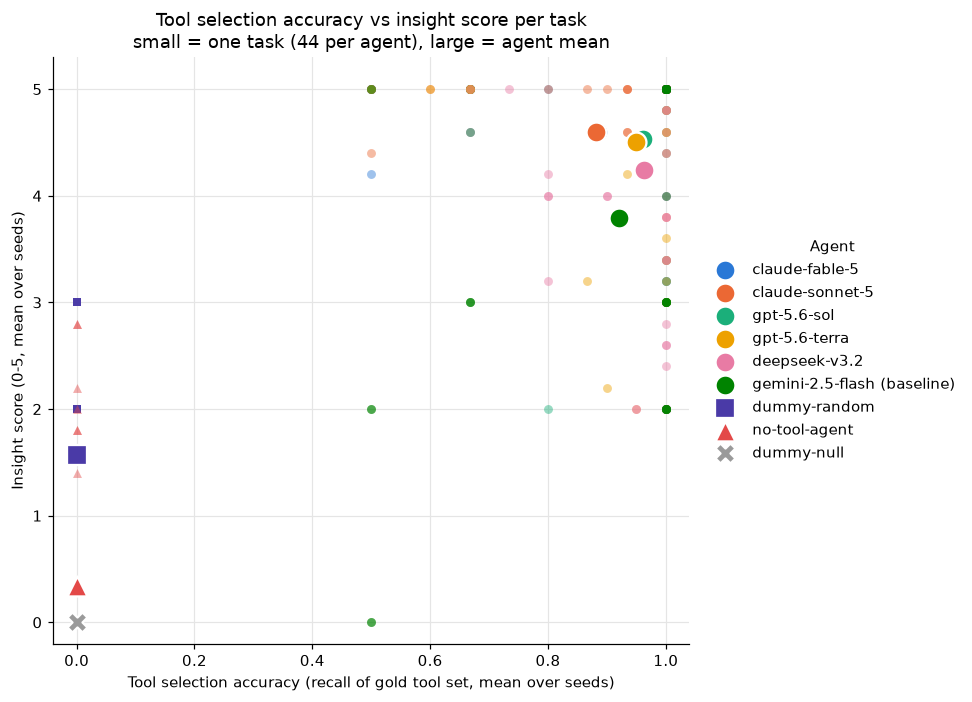

In [14]:
# one point per (agent, task): mean over seeds of both metrics
per_task_xy = (scores.groupby(["agent", "task_id"])[["tool_selection_accuracy", "insight_score"]]
               .mean().reset_index())
centroids = per_task_xy.groupby("agent")[["tool_selection_accuracy", "insight_score"]].mean()
corr = pd.Series({a: (g["tool_selection_accuracy"].corr(g["insight_score"])
                      if g["tool_selection_accuracy"].nunique() > 1 else np.nan)
                  for a, g in per_task_xy.groupby("agent")}, name="pearson_r")
print(centroids.join(corr).reindex(insight_by_type.index).round(3).to_string())

# fixed categorical order: eight palette slots for the eight scoring agents,
# neutral grey for the null dummy (a single point at the origin)
AGENT_COLORS = {
    "claude-fable-5": "#2a78d6", "claude-sonnet-5": "#eb6834", "gpt-5.6-sol": "#1baf7a",
    "gpt-5.6-terra": "#eda100", "deepseek-v3.2": "#e87ba4",
    "gemini-2.5-flash (baseline)": "#008300", "dummy-random": "#4a3aa7",
    "no-tool-agent": "#e34948", "dummy-null": "#9a9a9a"}
AGENT_MARKERS = {"dummy-random": "s", "no-tool-agent": "^", "dummy-null": "X"}

fig, ax = plt.subplots(figsize=(9, 6.5))
for agent in insight_by_type.index:
    g = per_task_xy[per_task_xy["agent"] == agent]
    c, m = AGENT_COLORS[agent], AGENT_MARKERS.get(agent, "o")
    ax.scatter(g["tool_selection_accuracy"], g["insight_score"], s=34, marker=m,
               color=c, alpha=0.45, linewidths=0, zorder=3)
    ax.scatter(centroids.loc[agent, "tool_selection_accuracy"],
               centroids.loc[agent, "insight_score"], s=170, marker=m, color=c,
               edgecolor="white", linewidths=1.5, zorder=4, label=agent)

ax.set_xlim(-0.04, 1.04)
ax.set_ylim(-0.2, 5.3)
ax.set_xlabel("Tool selection accuracy (recall of gold tool set, mean over seeds)")
ax.set_ylabel("Insight score (0-5, mean over seeds)")
ax.set_title("Tool selection accuracy vs insight score per task\n"
             "small = one task (44 per agent), large = agent mean")
ax.grid(True, color="#e5e5e5", zorder=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(title="Agent", frameon=False, loc="center left", bbox_to_anchor=(1.01, 0.5))
fig.tight_layout()
fig.savefig(REPO / "figures" / "tool_selection_vs_insight.png", dpi=150, bbox_inches="tight")
plt.show()

## Correlation of the metrics

Pearson correlation of the six benchmark metrics plus pass^k, computed over (agent, task) pairs with each metric averaged over seeds. Saved to `figures/metric_correlation_matrix.png`.

                         task_completion  insight_score  tool_selection_accuracy  path_efficiency  cost_usd  latency_s  pass^k
task_completion                     1.00           0.54                     0.48             0.57      0.04       0.19    0.34
insight_score                       0.54           1.00                     0.83             0.54      0.05       0.13    0.84
tool_selection_accuracy             0.48           0.83                     1.00             0.60      0.15       0.33    0.63
path_efficiency                     0.57           0.54                     0.60             1.00     -0.02       0.15    0.44
cost_usd                            0.04           0.05                     0.15            -0.02      1.00       0.35   -0.03
latency_s                           0.19           0.13                     0.33             0.15      0.35       1.00    0.02
pass^k                              0.34           0.84                     0.63             0.44     -0.03    

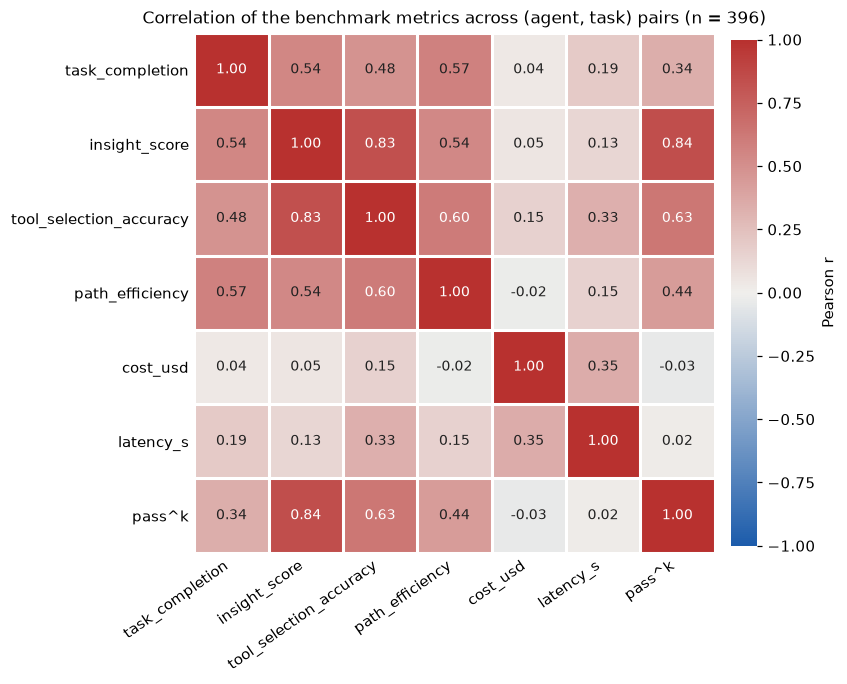

In [15]:
from matplotlib.colors import LinearSegmentedColormap
from cx_agent_bench.scoring import METRIC_COLS

# unit of analysis: one (agent, task) pair, each metric averaged over the seeds,
# joined with that pair's pass^k. 9 agents x 44 tasks = 396 rows, which is a far
# more stable basis than correlating the 9 agent-level rows of results.csv.
task_metrics = (scores.groupby(["agent", "task_id"])[METRIC_COLS].mean()
                .join(per_task.set_index(["agent", "task_id"])["pass_k"])
                .rename(columns={"pass_k": "pass^k"}))
corr_mat = task_metrics.corr()
print(corr_mat.round(2).to_string())

# diverging: blue (negative) <-> neutral grey <-> red (positive)
div_cmap = LinearSegmentedColormap.from_list("blue_grey_red",
                                             ["#1c5cab", "#f0efec", "#b8312f"])
names = corr_mat.columns.tolist()
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr_mat.values, cmap=div_cmap, vmin=-1, vmax=1)
ax.set_xticks(np.arange(-0.5, len(names)), minor=True)
ax.set_yticks(np.arange(-0.5, len(names)), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="both", length=0)
for i in range(len(names)):
    for j in range(len(names)):
        v = corr_mat.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(v) >= 0.6 else "#222222")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=35, ha="right")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
for side in ax.spines.values():
    side.set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
cbar.set_label("Pearson r")
cbar.outline.set_visible(False)
ax.set_title(f"Correlation of the benchmark metrics across (agent, task) pairs "
             f"(n = {len(task_metrics)})", fontsize=11)
fig.tight_layout()
fig.savefig(REPO / "figures" / "metric_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Insight score vs cost

Same layout as the tool-selection scatter, with cost per task on a log axis because the agents span two orders of magnitude. Agents that report no cost (the two dummies) are omitted. Saved to `figures/insight_vs_cost.png`.

                             cost_usd  insight_score
agent                                               
claude-fable-5                 0.2088         4.6000
claude-sonnet-5                0.0474         4.6000
gpt-5.6-sol                    0.0114         4.5364
gpt-5.6-terra                  0.0059         4.5000
deepseek-v3.2                  0.0030         4.2455
gemini-2.5-flash (baseline)    0.0126         3.7955
no-tool-agent                  0.0028         0.3364


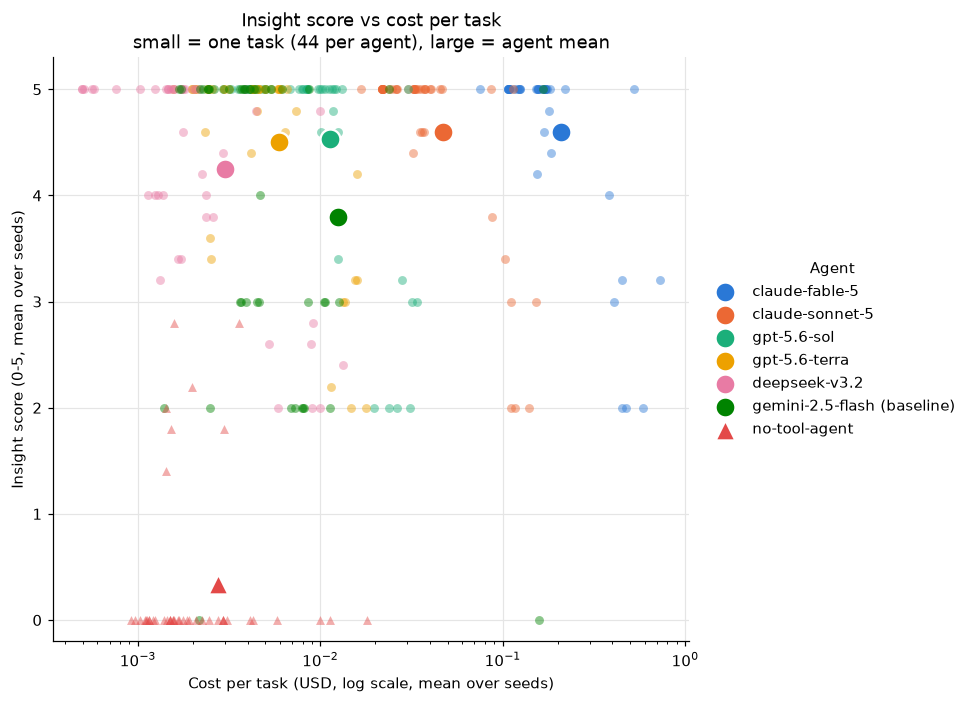

In [16]:
# one point per (agent, task): mean cost and insight over seeds. The dummies and
# the null run carry no cost and drop out; the no-tool ablation is kept.
cost_xy = (scores.groupby(["agent", "task_id"])[["cost_usd", "insight_score"]]
           .mean().reset_index().dropna(subset=["cost_usd"]))
cost_xy = cost_xy[cost_xy["cost_usd"] > 0]
cost_centroids = cost_xy.groupby("agent")[["cost_usd", "insight_score"]].mean()
print(cost_centroids.reindex([a for a in insight_by_type.index if a in cost_centroids.index])
      .round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 6.5))
for agent in insight_by_type.index:
    if agent not in cost_centroids.index:
        continue
    g = cost_xy[cost_xy["agent"] == agent]
    c, m = AGENT_COLORS[agent], AGENT_MARKERS.get(agent, "o")
    ax.scatter(g["cost_usd"], g["insight_score"], s=34, marker=m, color=c,
               alpha=0.45, linewidths=0, zorder=3)
    ax.scatter(cost_centroids.loc[agent, "cost_usd"], cost_centroids.loc[agent, "insight_score"],
               s=170, marker=m, color=c, edgecolor="white", linewidths=1.5, zorder=4,
               label=agent)
ax.set_xscale("log")
ax.set_ylim(-0.2, 5.3)
ax.set_xlabel("Cost per task (USD, log scale, mean over seeds)")
ax.set_ylabel("Insight score (0-5, mean over seeds)")
ax.set_title("Insight score vs cost per task\n"
             "small = one task (44 per agent), large = agent mean")
ax.grid(True, which="major", color="#e5e5e5", zorder=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(title="Agent", frameon=False, loc="center left", bbox_to_anchor=(1.01, 0.5))
fig.tight_layout()
fig.savefig(REPO / "figures" / "insight_vs_cost.png", dpi=150, bbox_inches="tight")
plt.show()